In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/content/drive/MyDrive/NVIDIA_STOCK.csv')
data.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,1/2/2018,4.929880,4.98375,4.98750,4.86250,4.89450,355616000
1,1/3/2018,5.254335,5.31175,5.34250,5.09375,5.10250,914704000
2,1/4/2018,5.282033,5.33975,5.45125,5.31725,5.39400,583268000
3,1/5/2018,5.326794,5.38500,5.42275,5.27700,5.35475,580124000
4,1/8/2018,5.490012,5.55000,5.62500,5.46450,5.51000,881216000


In [4]:
X = data[['Open','High','Low','Volume']]
y = data['Close']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Close   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.907e+06
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:35:23   Log-Likelihood:                -995.02
No. Observations:                1697   AIC:                             2000.
Df Residuals:                    1692   BIC:                             2027.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0267      0.030     -0.889      0.3

In [5]:
residuals = y - model.predict(X)
ssr = np.sum(residuals**2)
print(f'Sum of Squared Residuals (SSR): {ssr}')

Sum of Squared Residuals (SSR): 320.99503555115996


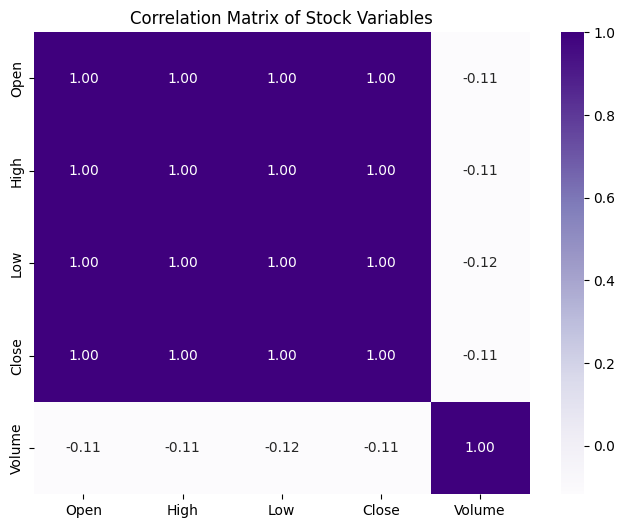

In [8]:
plt.figure(figsize=(8,6))
corr_matrix = data[["Open","High","Low","Close","Volume"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Purples", fmt=".2f")
plt.title("Correlation Matrix of Stock Variables")
plt.show()

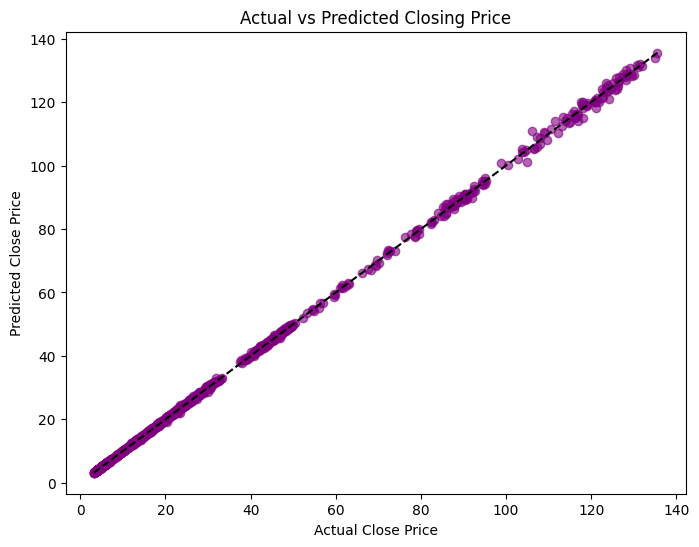

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(y, model.predict(X), alpha=0.6, color="purple")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="black", linestyle="--")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Closing Price")
plt.show()

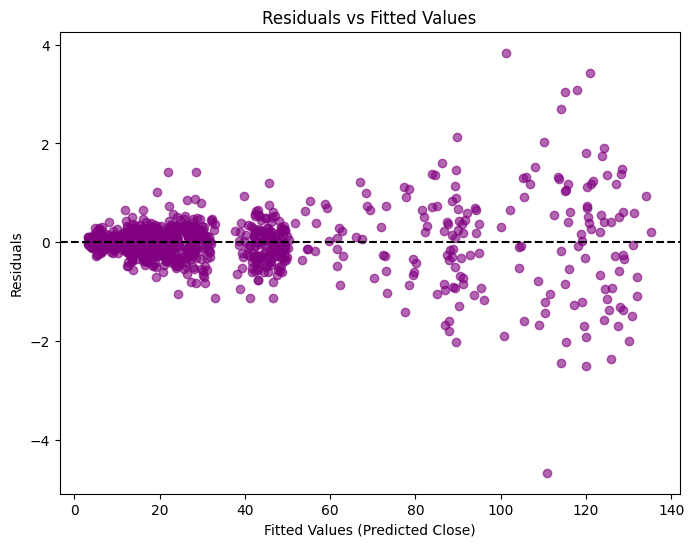

In [7]:
plt.figure(figsize=(8,6))
plt.scatter(model.predict(X),y - model.predict(X), alpha=0.6, color="purple")
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Fitted Values (Predicted Close)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()
